<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/BDSCAN_Ejer1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# 1. CREAR EL DATAFRAME
df = pd.read_csv('ejercicio_1_zonas_entrega.csv')

# Verificamos que se hayan cargado tus columnas X y Y
print(df.head())

  Punto    X    Y
0    P1  1.0  1.0
1    P2  1.2  1.3
2    P3  0.8  0.9
3    P4  1.1  1.0
4    P5  5.0  5.0


In [2]:
# 1. CREAR EL DATAFRAME DESDE EL CSV
# ==========================================
df = pd.read_csv('ejercicio_1_zonas_entrega.csv')
print("--- Primeras filas del DataFrame ---")
print(df.head())

--- Primeras filas del DataFrame ---
  Punto    X    Y
0    P1  1.0  1.0
1    P2  1.2  1.3
2    P3  0.8  0.9
3    P4  1.1  1.0
4    P5  5.0  5.0


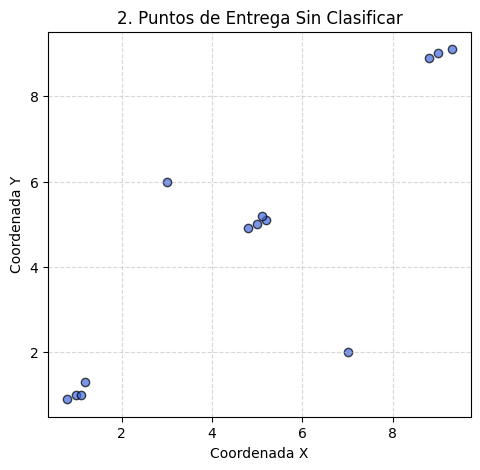

In [3]:
# 2. GRAFICAR LOS PUNTOS SIN CLASIFICAR
# ==========================================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['X'], df['Y'], color='royalblue', alpha=0.7, edgecolors='k')
plt.title('2. Puntos de Entrega Sin Clasificar')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.grid(True, linestyle='--', alpha=0.5)

In [4]:
# 3. APLICAR DBSCAN (eps=0.8, min_samples=3)
# ==========================================
# Seleccionamos las columnas X e Y para el algoritmo
X_train = df[['X', 'Y']]
dbscan = DBSCAN(eps=0.8, min_samples=3)
dbscan.fit(X_train)

DBSCAN(eps=0.8, min_samples=3)

In [5]:
# 4. AGREGAR COLUMNA CLUSTER
# ==========================================
df['Cluster'] = dbscan.labels_

<Axes: >

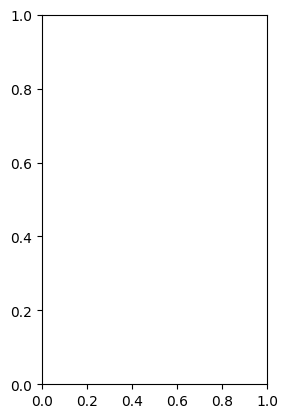

In [6]:
# 5. GRAFICAR CLUSTERS Y RESALTAR OUTLIERS
# ==========================================
plt.subplot(1, 2, 2)

In [7]:
# Separamos los puntos normales de los outliers (ruido)
outliers = df[df['Cluster'] == -1]
puntos_en_cluster = df[df['Cluster'] != -1]

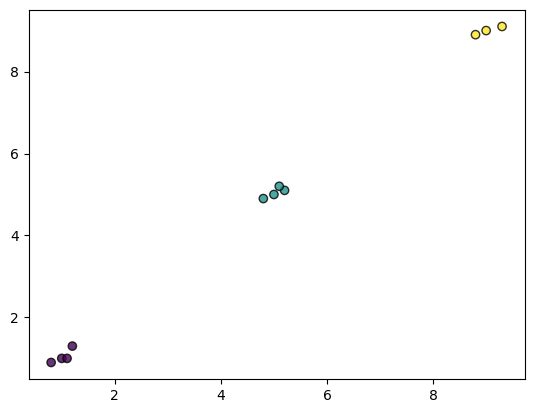

In [8]:
# Graficamos los clusters usando un mapa de color (cmap)
scatter = plt.scatter(puntos_en_cluster['X'], puntos_en_cluster['Y'],
                      c=puntos_en_cluster['Cluster'], cmap='viridis',
                      label='Zonas identificadas', edgecolors='k', alpha=0.8)

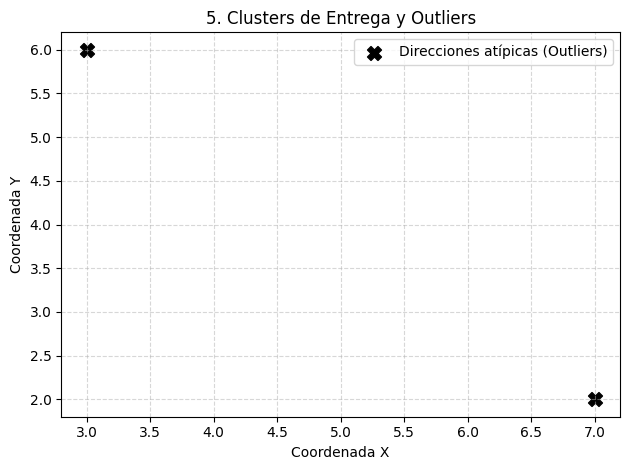

In [9]:
# Resaltamos los outliers en negro con una 'X'
plt.scatter(outliers['X'], outliers['Y'], color='black', marker='X',
            s=100, label='Direcciones atípicas (Outliers)')

plt.title('5. Clusters de Entrega y Outliers')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [10]:
# ==========================================
# 6. RESPUESTA A LA PREGUNTA
# ==========================================
# Los clusters válidos son todos los mayores o iguales a 0
num_clusters = len(set(df['Cluster'])) - (1 if -1 in df['Cluster'].values else 0)
num_outliers = len(outliers)

print("\n" + "="*40)
print(# RESPUESTA FINAL
f"6. RESULTADO DEL ALGORITMO:\n"
f"-> El algoritmo identificó {num_clusters} zonas de entrega de alta concentración.\n"
f"-> Se detectaron {num_outliers} direcciones atípicas (ruido/outliers).")
print("="*40)


6. RESULTADO DEL ALGORITMO:
-> El algoritmo identificó 3 zonas de entrega de alta concentración.
-> Se detectaron 2 direcciones atípicas (ruido/outliers).
